# Keypoint Training Pipeline Visualization

This notebook visualizes one random training sample through the same keypoint pipeline used in training:
1. original image
2. cropped player image (from COCO bbox)
3. letterbox-resized image
4. original keypoints
5. normalized/cropped keypoints
6. heatmap targets

## Setup

In [50]:
import os
import sys
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "training":
    PROJECT_ROOT = PROJECT_ROOT.parent.parent
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from data.keypoint_dataset import TennisKeypointDataset
from preprocessing.pil_preprocessing import letterbox_resize
from train.keypoint_train import KeypointsToHeatmaps

# SEED = 42
# random.seed(SEED)
# np.random.seed(SEED)

ROOT_DIR = PROJECT_ROOT / "datasets/orvile/tennis-player-actions-dataset/versions/1/Tennis Player Actions Dataset for Human Pose Estimation"
ANNOTATION_DIR = "annotations"
IMAGE_SIZE = (128, 128)  # (height, width)
NUM_KEYPOINTS = 18
HEATMAP_SIGMA = 2.0

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset root: {ROOT_DIR}")

Project root: /Users/hanyiliu/Documents/GitHub/tennis-pose-detection
Dataset root: /Users/hanyiliu/Documents/GitHub/tennis-pose-detection/datasets/orvile/tennis-player-actions-dataset/versions/1/Tennis Player Actions Dataset for Human Pose Estimation


## 1) Image Pipeline Stages

Random sample: original image → cropped image (bbox) → letterbox resized image.

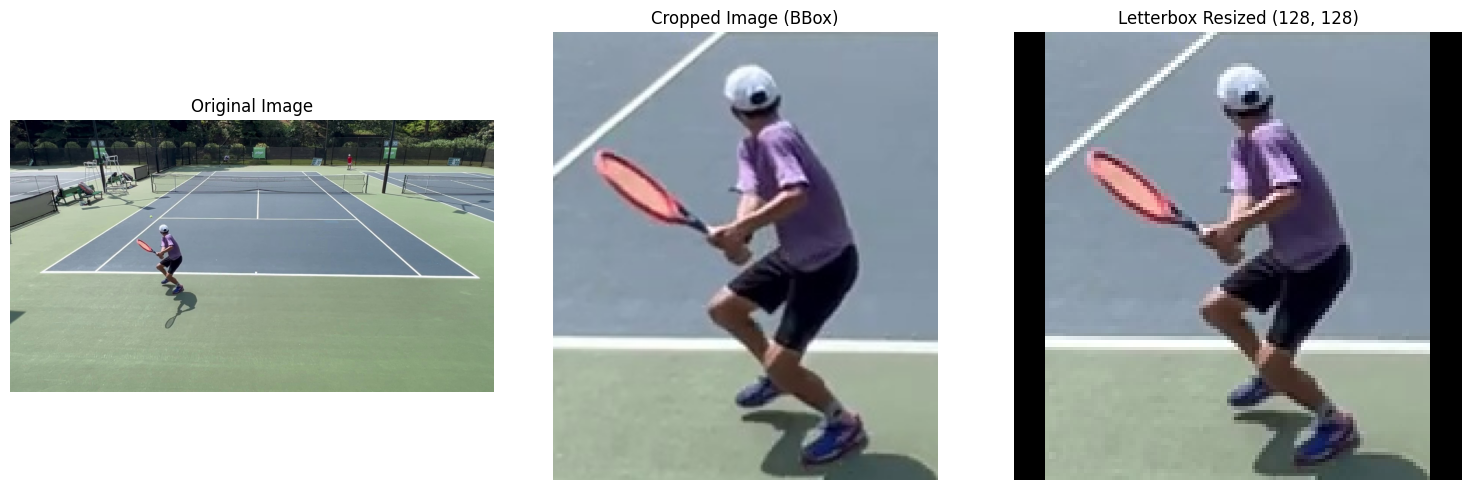

Sample index: 4
Image path: /Users/hanyiliu/Documents/GitHub/tennis-pose-detection/datasets/orvile/tennis-player-actions-dataset/versions/1/Tennis Player Actions Dataset for Human Pose Estimation/images/backhand/B_005.jpeg
BBox [x, y, w, h]: [316, 263, 176, 205]


In [51]:
dataset_for_visual = TennisKeypointDataset(
    root_dir=str(ROOT_DIR),
    annotation_dir=ANNOTATION_DIR,
    image_transform=None,
    keypoint_transform=None,
)

# sample_idx = random.randrange(len(dataset_for_visual))
sample_idx = 4
raw_sample = dataset_for_visual.data[sample_idx]

img_path = raw_sample["img_path"]
bbox = raw_sample["bbox"]
x, y, w, h = bbox

original_img = Image.open(img_path).convert("RGB")
cropped_img, normalized_keypoints_tensor = dataset_for_visual[sample_idx]
letterboxed_img = letterbox_resize(cropped_img.copy(), IMAGE_SIZE)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(original_img)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(cropped_img)
axes[1].set_title("Cropped Image (BBox)")
axes[1].axis("off")

axes[2].imshow(letterboxed_img)
axes[2].set_title(f"Letterbox Resized {IMAGE_SIZE}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print(f"Sample index: {sample_idx}")
print(f"Image path: {img_path}")
print(f"BBox [x, y, w, h]: {bbox}")

## 2) Keypoint Vector Stages

Original keypoints (full-image coordinates) → normalized cropped keypoints (bbox-local coordinates).

In [52]:
original_keypoints = np.array(raw_sample["keypoints"], dtype=np.float32).reshape(NUM_KEYPOINTS, 3)
normalized_keypoints = normalized_keypoints_tensor.numpy()

print("Original keypoint vector shape:", original_keypoints.shape)
print("Original keypoints (x, y, visibility):")
print(original_keypoints)

print("\nNormalized + cropped keypoint vector shape:", normalized_keypoints.shape)
print("Normalized keypoints (x_norm, y_norm, visibility):")
print(normalized_keypoints)

Original keypoint vector shape: (18, 3)
Original keypoints (x, y, visibility):
[[410. 294.   1.]
 [401. 292.   1.]
 [414. 288.   1.]
 [399. 299.   2.]
 [420. 294.   2.]
 [418. 313.   2.]
 [403. 313.   2.]
 [428. 341.   2.]
 [406. 338.   2.]
 [399. 353.   2.]
 [405. 359.   1.]
 [446. 371.   2.]
 [420. 364.   2.]
 [416. 419.   2.]
 [390. 392.   2.]
 [453. 442.   2.]
 [423. 422.   1.]
 [412. 303.   2.]]

Normalized + cropped keypoint vector shape: (18, 3)
Normalized keypoints (x_norm, y_norm, visibility):
[[0.53409094 0.15121952 1.        ]
 [0.48295453 0.14146341 1.        ]
 [0.5568182  0.12195122 1.        ]
 [0.4715909  0.17560975 2.        ]
 [0.59090906 0.15121952 2.        ]
 [0.57954544 0.24390244 2.        ]
 [0.4943182  0.24390244 2.        ]
 [0.6363636  0.3804878  2.        ]
 [0.5113636  0.36585367 2.        ]
 [0.4715909  0.4390244  2.        ]
 [0.5056818  0.46829268 1.        ]
 [0.7386364  0.52682924 2.        ]
 [0.59090906 0.49268293 2.        ]
 [0.5681818  0.7609756  

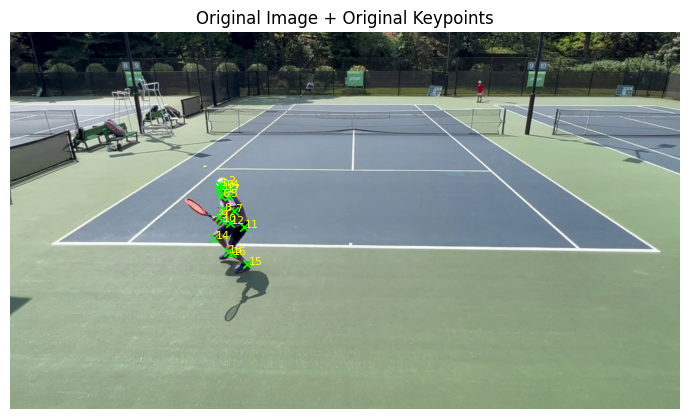

In [53]:
if "original_keypoints" not in globals():
    original_keypoints = np.array(raw_sample["keypoints"], dtype=np.float32).reshape(NUM_KEYPOINTS, 3)
if "original_img" not in globals():
    original_img = Image.open(img_path).convert("RGB")

orig_visible_mask = original_keypoints[:, 2] > 0

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(original_img)
ax.scatter(
    original_keypoints[orig_visible_mask, 0],
    original_keypoints[orig_visible_mask, 1],
    c="lime",
    s=36,
    marker="x",
    linewidths=1.2,
)

for i in np.where(orig_visible_mask)[0]:
    xk, yk = original_keypoints[i, 0], original_keypoints[i, 1]
    ax.text(xk + 2.0, yk + 2.0, str(i), color="yellow", fontsize=8)

ax.set_title("Original Image + Original Keypoints")
ax.axis("off")
plt.tight_layout()
plt.show()

## 3) Heatmap Conversion Stage

Normalized cropped keypoints → heatmap target tensor used by keypoint training.

Heatmap tensor shape: (18, 128, 128)
Heatmap min/max: 0.0 0.9999226927757263


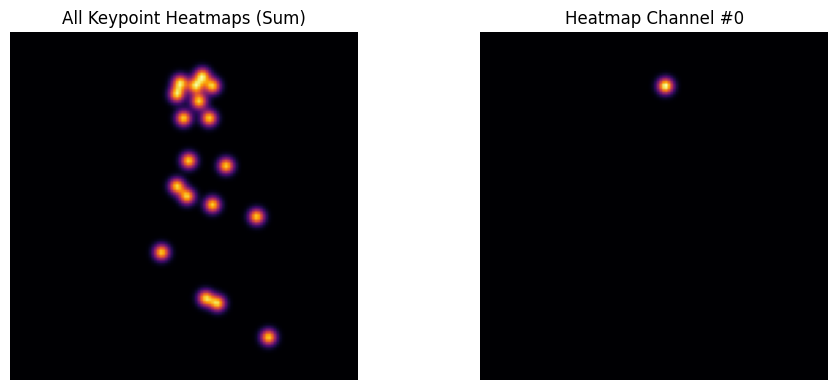

In [54]:
heatmap_transform = KeypointsToHeatmaps(
    out_size=IMAGE_SIZE,
    num_keypoints=NUM_KEYPOINTS,
    sigma=HEATMAP_SIGMA,
)

heatmaps = heatmap_transform(normalized_keypoints, float(w), float(h))

print("Heatmap tensor shape:", heatmaps.shape)
print("Heatmap min/max:", float(heatmaps.min()), float(heatmaps.max()))

visible_idxs = np.where(normalized_keypoints[:, 2] > 0)[0]
example_kp_idx = int(visible_idxs[0]) if len(visible_idxs) > 0 else 0

summed_heatmap = heatmaps.sum(axis=0)
example_heatmap = heatmaps[example_kp_idx]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(summed_heatmap, cmap="inferno")
axes[0].set_title("All Keypoint Heatmaps (Sum)")
axes[0].axis("off")

axes[1].imshow(example_heatmap, cmap="inferno")
axes[1].set_title(f"Heatmap Channel #{example_kp_idx}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 4) Letterbox Image + Heatmap Views

This section shows:
1) the letterbox-resized image next to the summed keypoint heatmap, and
2) an overlay view of the heatmap on top of the letterbox image.

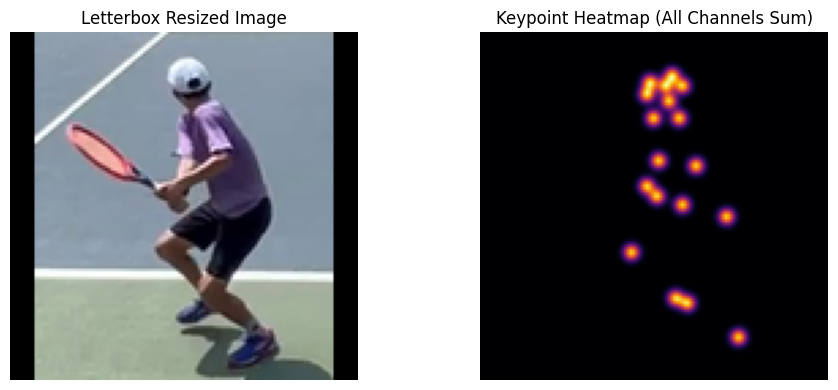

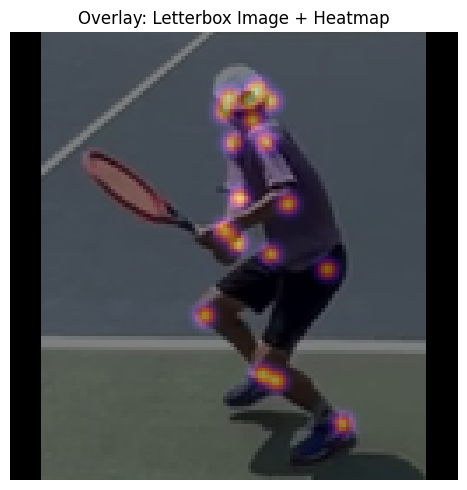

In [55]:
heatmap_overlay = summed_heatmap
letterboxed_np = np.array(letterboxed_img)

# View 1: side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(letterboxed_img)
axes[0].set_title("Letterbox Resized Image")
axes[0].axis("off")

axes[1].imshow(heatmap_overlay, cmap="inferno")
axes[1].set_title("Keypoint Heatmap (All Channels Sum)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# View 2: overlay
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(letterboxed_np)
ax.imshow(heatmap_overlay, cmap="inferno", alpha=0.5)
ax.set_title("Overlay: Letterbox Image + Heatmap")
ax.axis("off")

plt.tight_layout()
plt.show()

## 5) Letterbox Image + Normalized Keypoint Points

This plot overlays the normalized keypoint vector points on the letterbox-resized image.

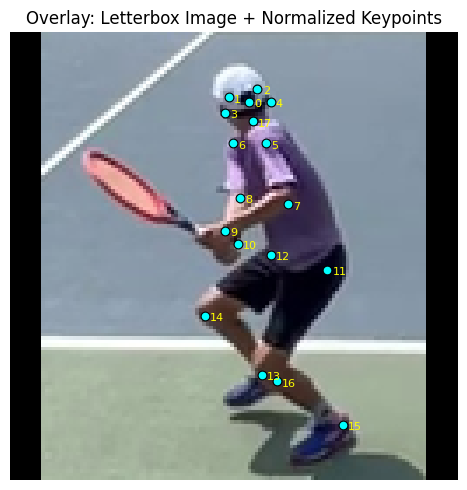

In [56]:
out_h, out_w = IMAGE_SIZE
bbox_w = float(w)
bbox_h = float(h)

scale = min(out_w / bbox_w, out_h / bbox_h)
resized_w = bbox_w * scale
resized_h = bbox_h * scale
pad_x = (out_w - resized_w) / 2.0
pad_y = (out_h - resized_h) / 2.0

kp = normalized_keypoints.copy()
visible_mask = kp[:, 2] > 0

x_crop = np.clip(kp[:, 0], 0.0, 1.0) * bbox_w
y_crop = np.clip(kp[:, 1], 0.0, 1.0) * bbox_h
x_letterbox = x_crop * scale + pad_x
y_letterbox = y_crop * scale + pad_y

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(letterboxed_img)
ax.scatter(
    x_letterbox[visible_mask],
    y_letterbox[visible_mask],
    c="cyan",
    s=40,
    edgecolors="black",
    linewidths=0.8,
)

for i in np.where(visible_mask)[0]:
    ax.text(x_letterbox[i] + 1.5, y_letterbox[i] + 1.5, str(i), color="yellow", fontsize=8)

ax.set_title("Overlay: Letterbox Image + Normalized Keypoints")
ax.axis("off")
plt.tight_layout()
plt.show()

## 6) Inference with Exported Best Model (Logits -> Probabilities)

The trained model now outputs **logits** (for `BCEWithLogitsLoss`).
This section converts logits to probabilities with sigmoid for visualization and diagnostics.

Loaded model from: /Users/hanyiliu/Documents/GitHub/tennis-pose-detection/exports/keypoint_best_state_dict.pt
Predicted logits shape: (18, 128, 128)
Logits min/max: -52.12962341308594 7.348197937011719
Probability min/max: 2.2929375014508605e-23 0.9993566870689392


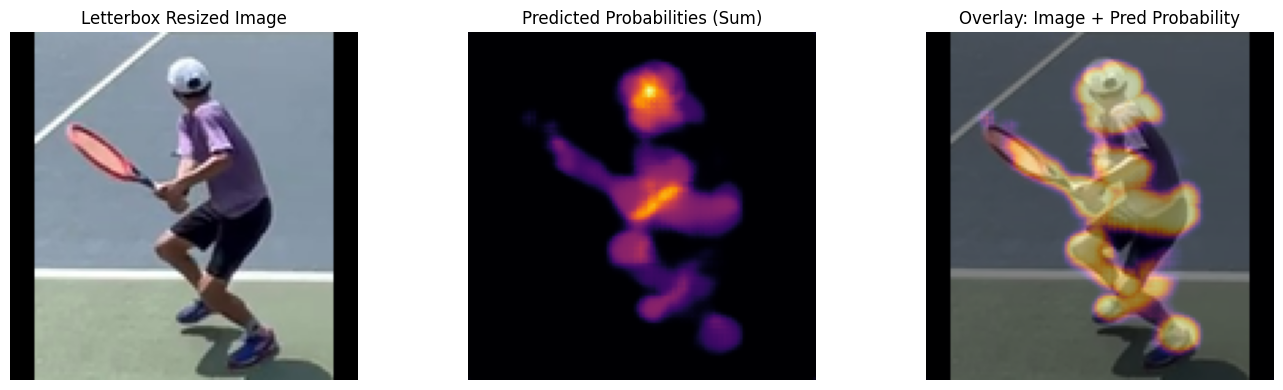

In [57]:
import torch
from models.keypoint_detection import KeypointDetectionModel

state_dict_path = PROJECT_ROOT / "exports" / "keypoint_best_state_dict.pt"
torchscript_path = PROJECT_ROOT / "exports" / "keypoint_best_torchscript.pt"

if state_dict_path.exists():
    checkpoint = torch.load(state_dict_path, map_location="cpu")
    if isinstance(checkpoint, dict) and "model_state" in checkpoint:
        state_dict = checkpoint["model_state"]
    elif isinstance(checkpoint, dict):
        state_dict = checkpoint
    else:
        raise ValueError("Unsupported state_dict export format. Expected dict or dict with 'model_state'.")

    model_infer = KeypointDetectionModel(num_keypoints=NUM_KEYPOINTS)
    model_infer.load_state_dict(state_dict)
    model_infer.eval()
    loaded_from = state_dict_path
elif torchscript_path.exists():
    model_infer = torch.jit.load(torchscript_path, map_location="cpu")
    model_infer.eval()
    loaded_from = torchscript_path
else:
    raise FileNotFoundError(
        f"No keypoint export found. Checked: {state_dict_path} and {torchscript_path}"
    )

img_tensor = torch.from_numpy(np.array(letterboxed_img)).float() / 255.0
img_tensor = img_tensor.permute(2, 0, 1).unsqueeze(0)

with torch.no_grad():
    pred_logits = model_infer(img_tensor).squeeze(0).cpu().numpy()  # (K, H, W)

pred_probs = 1.0 / (1.0 + np.exp(-pred_logits))
pred_heatmap_sum = pred_probs.sum(axis=0)
pred_heatmap_max = pred_probs.max(axis=0)

print(f"Loaded model from: {loaded_from}")
print("Predicted logits shape:", pred_logits.shape)
print("Logits min/max:", float(pred_logits.min()), float(pred_logits.max()))
print("Probability min/max:", float(pred_probs.min()), float(pred_probs.max()))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(letterboxed_img)
axes[0].set_title("Letterbox Resized Image")
axes[0].axis("off")

axes[1].imshow(pred_heatmap_sum, cmap="inferno")
axes[1].set_title("Predicted Probabilities (Sum)")
axes[1].axis("off")

axes[2].imshow(letterboxed_img)
axes[2].imshow(pred_heatmap_max, cmap="inferno", alpha=0.5)
axes[2].set_title("Overlay: Image + Pred Probability")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## 7) Channel-wise Argmax Keypoints (Max per Channel)

This section takes the **maximum value location** from each predicted probability channel as that channel's keypoint.

It visualizes:
1) each channel individually with its argmax keypoint, then
2) all extracted keypoints overlaid on the letterbox image.

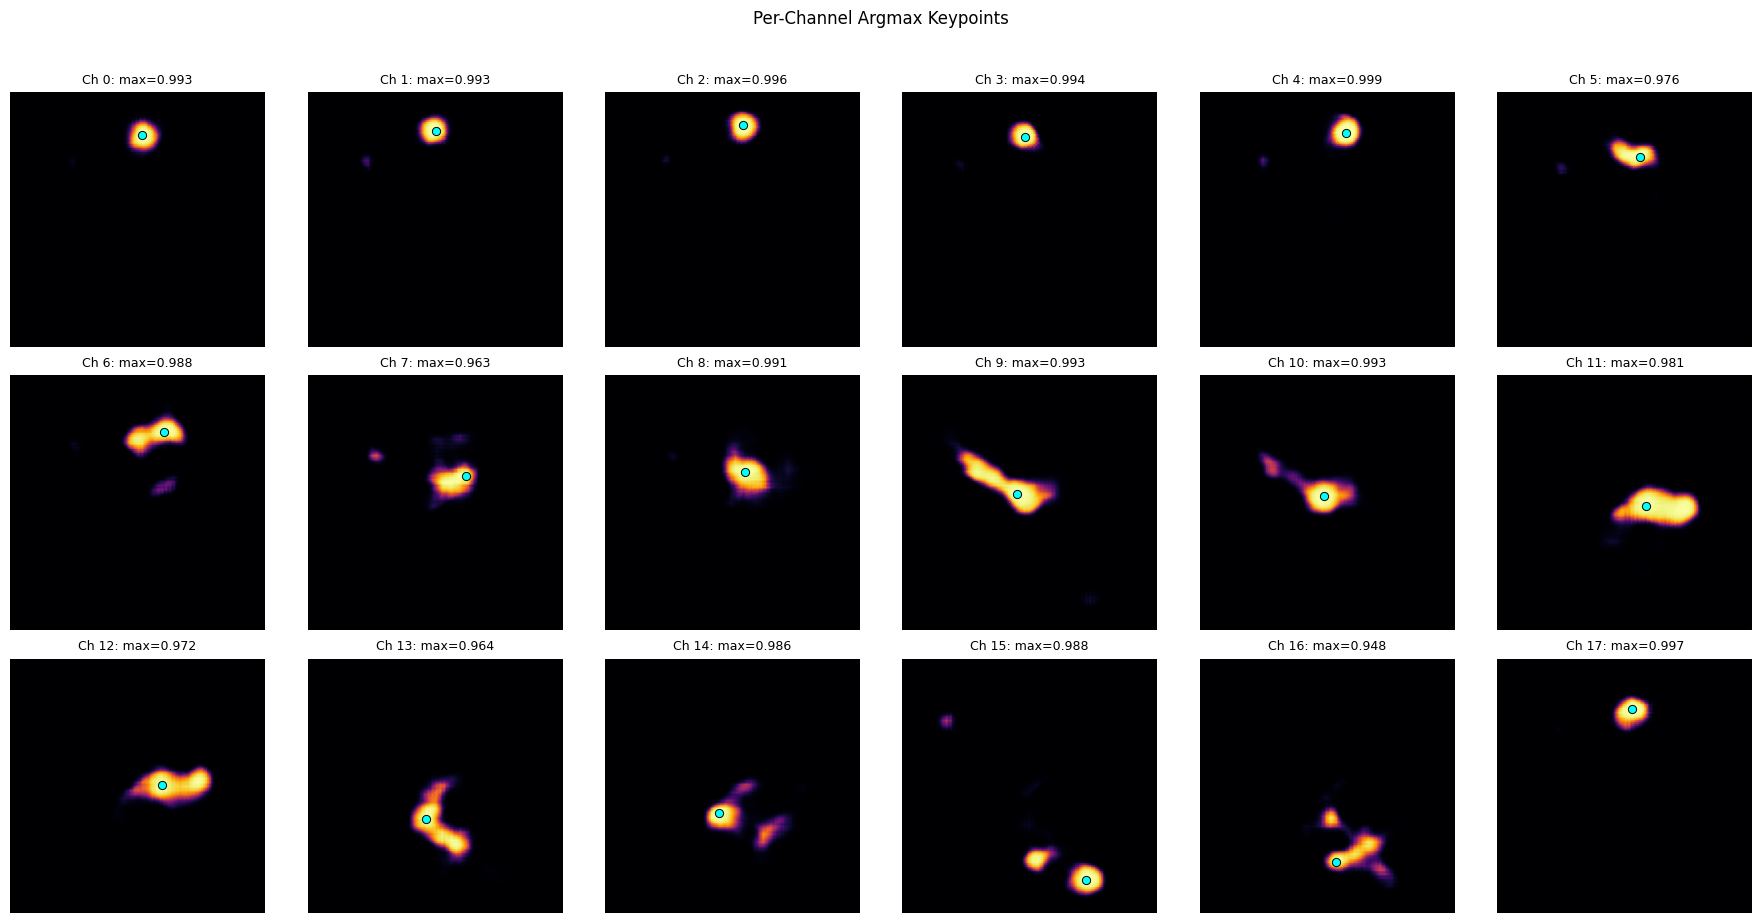

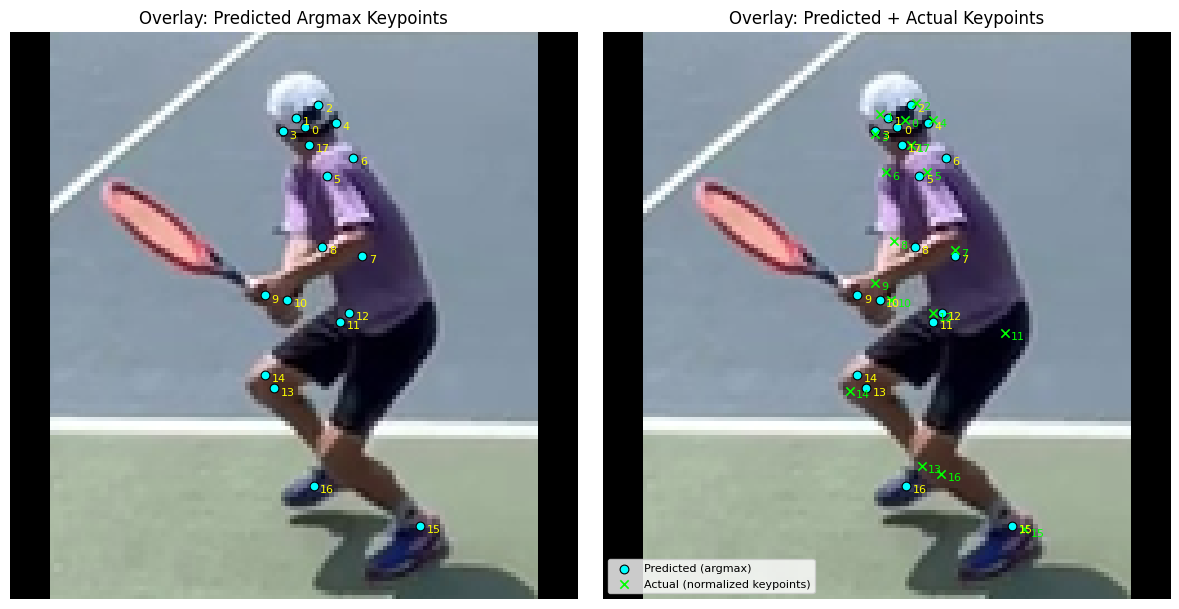

Argmax keypoints shape (K, 3): (18, 3)
Columns: [x, y, confidence]
[[ 66.          21.           0.9926967 ]
 [ 64.          19.           0.99268204]
 [ 69.          16.           0.9959489 ]
 [ 61.          22.           0.99394894]
 [ 73.          20.           0.9993567 ]
 [ 71.          32.           0.9756139 ]
 [ 77.          28.           0.98803794]
 [ 79.          50.           0.9633687 ]
 [ 70.          48.           0.99066776]
 [ 57.          59.           0.9932568 ]
 [ 62.          60.           0.99298054]
 [ 74.          65.           0.98134077]
 [ 76.          63.           0.97215545]
 [ 59.          80.           0.9639185 ]
 [ 57.          77.           0.9861908 ]
 [ 92.         111.           0.98773694]
 [ 68.         102.           0.9476865 ]
 [ 67.          25.           0.99662787]]


In [58]:
if "pred_probs" not in globals():
    raise RuntimeError("Run Section 6 first so `pred_probs` is available.")

num_channels, hm_h, hm_w = pred_probs.shape
pred_keypoints_argmax = np.zeros((num_channels, 3), dtype=np.float32)  # x, y, confidence

for ch in range(num_channels):
    heat_ch = pred_probs[ch]
    flat_idx = int(np.argmax(heat_ch))
    y_peak, x_peak = np.unravel_index(flat_idx, heat_ch.shape)
    conf = float(heat_ch[y_peak, x_peak])
    pred_keypoints_argmax[ch] = [x_peak, y_peak, conf]

# 1) Visualize each channel individually
n_cols = 6
n_rows = int(np.ceil(num_channels / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
axes = np.array(axes).reshape(n_rows, n_cols)

for ch in range(n_rows * n_cols):
    ax = axes.flat[ch]
    if ch < num_channels:
        heat_ch = pred_probs[ch]
        x_peak, y_peak, conf = pred_keypoints_argmax[ch]
        ax.imshow(heat_ch, cmap="inferno")
        ax.scatter([x_peak], [y_peak], c="cyan", s=35, edgecolors="black", linewidths=0.7)
        ax.set_title(f"Ch {ch}: max={conf:.3f}", fontsize=9)
        ax.axis("off")
    else:
        ax.axis("off")

plt.suptitle("Per-Channel Argmax Keypoints", y=1.02)
plt.tight_layout()
plt.show()

# Convert actual normalized keypoints to letterbox coordinates
out_h, out_w = IMAGE_SIZE
bbox_w = float(w)
bbox_h = float(h)
scale = min(out_w / bbox_w, out_h / bbox_h)
resized_w = bbox_w * scale
resized_h = bbox_h * scale
pad_x = (out_w - resized_w) / 2.0
pad_y = (out_h - resized_h) / 2.0

kp_actual = normalized_keypoints.copy()
actual_visible_mask = kp_actual[:, 2] > 0
actual_x_crop = np.clip(kp_actual[:, 0], 0.0, 1.0) * bbox_w
actual_y_crop = np.clip(kp_actual[:, 1], 0.0, 1.0) * bbox_h
actual_x_letterbox = actual_x_crop * scale + pad_x
actual_y_letterbox = actual_y_crop * scale + pad_y

# 2) Overlay views: predicted only (left), predicted + actual (right)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(letterboxed_img)
axes[0].scatter(
    pred_keypoints_argmax[:, 0],
    pred_keypoints_argmax[:, 1],
    c="cyan",
    s=40,
    edgecolors="black",
    linewidths=0.8,
)
for idx, (xk, yk, conf) in enumerate(pred_keypoints_argmax):
    axes[0].text(xk + 1.5, yk + 1.5, str(idx), color="yellow", fontsize=8)
axes[0].set_title("Overlay: Predicted Argmax Keypoints")
axes[0].axis("off")

axes[1].imshow(letterboxed_img)
axes[1].scatter(
    pred_keypoints_argmax[:, 0],
    pred_keypoints_argmax[:, 1],
    c="cyan",
    s=40,
    edgecolors="black",
    linewidths=0.8,
    label="Predicted (argmax)",
)
axes[1].scatter(
    actual_x_letterbox[actual_visible_mask],
    actual_y_letterbox[actual_visible_mask],
    c="lime",
    s=36,
    marker="x",
    linewidths=1.2,
    label="Actual (normalized keypoints)",
)
for idx, (xk, yk, conf) in enumerate(pred_keypoints_argmax):
    axes[1].text(xk + 1.5, yk + 1.5, str(idx), color="yellow", fontsize=8)
for idx in np.where(actual_visible_mask)[0]:
    axes[1].text(actual_x_letterbox[idx] + 1.5, actual_y_letterbox[idx] + 1.5, str(idx), color="lime", fontsize=8)
axes[1].set_title("Overlay: Predicted + Actual Keypoints")
axes[1].legend(loc="lower left", fontsize=8)
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("Argmax keypoints shape (K, 3):", pred_keypoints_argmax.shape)
print("Columns: [x, y, confidence]")
print(pred_keypoints_argmax)

## Evaluation

Measure PCK against all data, using `heatmap_keypoint_accuracy()` from `keypoint_train.py`.

In [59]:
from train.keypoint_train import heatmap_keypoint_accuracy

dataset_eval = TennisKeypointDataset(
    root_dir=str(ROOT_DIR),
    annotation_dir=ANNOTATION_DIR,
    image_transform=None,
    keypoint_transform=None,
)

def to_scalar_metric(metric_obj):
    if isinstance(metric_obj, (int, float, np.floating)):
        return float(metric_obj)
    if isinstance(metric_obj, dict):
        # common keys first
        for k in ["pck", "accuracy", "acc", "mean_pck", "mean_accuracy"]:
            if k in metric_obj and isinstance(metric_obj[k], (int, float, np.floating)):
                return float(metric_obj[k])
        # fallback: first numeric value
        for v in metric_obj.values():
            if isinstance(v, (int, float, np.floating)):
                return float(v)
    if isinstance(metric_obj, (list, tuple)) and len(metric_obj) > 0:
        vals = [float(v) for v in metric_obj if isinstance(v, (int, float, np.floating))]
        if len(vals) > 0:
            return float(np.mean(vals))
    return None

scores = []
failed = 0

for i in range(len(dataset_eval)):
    raw = dataset_eval.data[i]
    _, norm_kp_tensor = dataset_eval[i]  # cropped image + normalized keypoints
    x, y, w, h = raw["bbox"]

    cropped_img, _ = dataset_eval[i]
    lb_img = letterbox_resize(cropped_img.copy(), IMAGE_SIZE)

    img_tensor = torch.from_numpy(np.array(lb_img)).float() / 255.0
    img_tensor = img_tensor.permute(2, 0, 1).unsqueeze(0)

    with torch.no_grad():
        pred_logits = model_infer(img_tensor).squeeze(0).cpu().numpy()  # (K,H,W)
    pred_probs = 1.0 / (1.0 + np.exp(-pred_logits))

    target_heatmaps = heatmap_transform(norm_kp_tensor.numpy(), float(w), float(h))

    # Try common calling patterns for heatmap_keypoint_accuracy
    metric_out = None
    try:
        metric_out = heatmap_keypoint_accuracy(
            torch.from_numpy(pred_probs).unsqueeze(0),
            torch.from_numpy(target_heatmaps).unsqueeze(0),
        )
    except Exception:
        try:
            metric_out = heatmap_keypoint_accuracy(
                pred_probs[np.newaxis, ...],
                target_heatmaps[np.newaxis, ...],
            )
        except Exception:
            failed += 1
            continue

    score = to_scalar_metric(metric_out)
    if score is None:
        failed += 1
    else:
        scores.append(score)

print(f"Evaluated samples: {len(scores)} / {len(dataset_eval)}")
print(f"Failed samples: {failed}")
if len(scores) > 0:
    print(f"Mean PCK/accuracy: {np.mean(scores):.4f}")
    print(f"Median PCK/accuracy: {np.median(scores):.4f}")
    print(f"Min/Max: {np.min(scores):.4f} / {np.max(scores):.4f}")
else:
    print("No valid evaluation scores produced. Check `heatmap_keypoint_accuracy` expected inputs.")

/var/folders/3k/zs813cfd5_36pyy2p9xmz4_80000gn/T/ipykernel_41576/1290189042.py:44: RuntimeWarning: overflow encountered in exp
  pred_probs = 1.0 / (1.0 + np.exp(-pred_logits))


Evaluated samples: 1994 / 1994
Failed samples: 0
Mean PCK/accuracy: 0.9245
Median PCK/accuracy: 0.9444
Min/Max: 0.2778 / 1.0000
